In [1]:
import os
import fnmatch
import pandas as pd
import json
#########################################
### Data Preprocessing (Local setup)
#######################################
# def delete_non_filtered_tif_files(folder_path):
#     # Deletes all files starting with 'Non-Filtered' and with the '.tif' extension
#     # from the specified folder and its subfolders.
#     if not os.path.isdir(folder_path):
#         print(f"Error: The folder '{folder_path}' does not exist.")
#         return

#     # Traverse the folder and its subfolders
#     for root, dirs, files in os.walk(folder_path):
#         for filename in files:
#             # Check if the file matches the naming criteria
#             if fnmatch.fnmatch(filename, 'Non-Filtered*.tif'):
#                 file_path = os.path.join(root, filename)
#                 try:
#                     os.remove(file_path)
#                     print(f"Deleted: {file_path}")
#                 except Exception as e:
#                     print(f"Error deleting file '{file_path}': {e}")

# if __name__ == "__main__":

#     target_folder = './'
#     delete_non_filtered_tif_files(target_folder)

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)

# print(path_list)

# for path in path_list:
#     # path = './Random_series_001'
#     data = pd.read_csv(f'{path}/image_data.csv')
#     df = pd.DataFrame(data)
#     df = df.drop(['BaS', 'Sn2BaS3', 'SnS', 'BaS_thickness_cm', 'Sn2BaS3_thickness_cm', 'SnS_thickness_cm'], axis=1)

#     with open(f'{path}/settings.json', 'r') as f:
#         settings = json.load(f)

#     boundary1 = settings['boundaries'][1]
#     boundary2 = settings['boundaries'][2]

#     df['target_1'] = df['F'].apply(lambda x: 1 if x < boundary1 else 0)
#     df['target_2'] = df['F'].apply(lambda x: 1 if x >= boundary1 and x <= boundary2 else 0)
#     df['target_3'] = df['F'].apply(lambda x: 1 if x > boundary2 else 0)

#     df.to_csv(f'{path}/image_data_1.csv', index=False)

# print(df.head())
# print(settings['boundaries'])


###########################################
## TRAIN - VAL - TEST (Local setup)
###########################################

# path_list = []
# for root, dirs, files in os.walk('./'):
#     # print(root)
#     if len(root)>2:
#         path_list.append(root)


# train_directories = path_list[:100]
# val_directories = path_list[100:150]
# test_directories = path_list[150:]

# print(train_directories)
# print(val_directories)
# print(test_directories)

# combined_data = pd.DataFrame()
# for directory in train_directories:
#     file_path = os.path.join(directory, 'image_data_1.csv')

#     if os.path.exists(file_path):
#         df = pd.read_csv(file_path)

#         combined_data = pd.concat([combined_data, df], ignore_index=True)
#     else:
#         print(f"File not found: {file_path}")

# combined_data.to_csv('train_data.csv', index=False)

# print("Data combined successfully into 'train_data.csv'.")

# combined_data = pd.DataFrame()
# for directory in val_directories:
#     file_path = os.path.join(directory, 'image_data_1.csv')

#     if os.path.exists(file_path):
#         df = pd.read_csv(file_path)

#         combined_data = pd.concat([combined_data, df], ignore_index=True)
#     else:
#         print(f"File not found: {file_path}")

# combined_data.to_csv('val_data.csv', index=False)

# print("Data combined successfully into 'val_data.csv'.")

# combined_data = pd.DataFrame()
# for directory in test_directories:
#     file_path = os.path.join(directory, 'image_data_1.csv')

#     if os.path.exists(file_path):
#         df = pd.read_csv(file_path)

#         combined_data = pd.concat([combined_data, df], ignore_index=True)
#     else:
#         print(f"File not found: {file_path}")

# combined_data.to_csv('test_data.csv', index=False)

# print("Data combined successfully into 'test_data.csv'.")

In [111]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression


In [112]:
train_data = pd.read_csv('train_data.csv')
val_data = pd.read_csv('val_data.csv')
test_data = pd.read_csv('test_data.csv')

train_data.head()

,x,y,Sn,Ba,F,target
0,-2.49,-0.49,1.926823e-07,2.864439e-07,0.402154,1
1,-2.49,-0.44,1.920718e-07,2.853302e-07,0.402327,1
2,-2.49,-0.39,1.914566e-07,2.842045e-07,0.402506,1
3,-2.49,-0.34,1.908368e-07,2.830671e-07,0.402691,1
4,-2.49,-0.29,1.902124e-07,2.819184e-07,0.402881,1


In [ ]:
train_data.shape

(809200, 9)

In [ ]:
test_data.shape

(404600, 9)

In [ ]:
# val_data.head(), test_data.head()

In [113]:
train_data['log_Sn'] = np.log(train_data['Sn'] * 1e7  + 1)
train_data['log_Ba'] = np.log(train_data['Ba'] * 1e7  + 1)
# train_data['log_F'] = np.log(train_data['F'] + 1)

val_data['log_Sn'] = np.log(val_data['Sn'] * 1e7  + 1)
val_data['log_Ba'] = np.log(val_data['Ba'] * 1e7  + 1)
# val_data['log_F'] = np.log(val_data['F'] + 1)

test_data['log_Sn'] = np.log(test_data['Sn'] * 1e7  + 1)
test_data['log_Ba'] = np.log(test_data['Ba'] * 1e7  + 1)
# test_data['log_F'] = np.log(test_data['F'] + 1)

In [114]:
train_data.head()

,x,y,Sn,Ba,F,target,log_Sn,log_Ba
0,-2.49,-0.49,1.926823e-07,2.864439e-07,0.402154,1,1.073917,1.351817
1,-2.49,-0.44,1.920718e-07,2.853302e-07,0.402327,1,1.071830,1.348930
2,-2.49,-0.39,1.914566e-07,2.842045e-07,0.402506,1,1.069721,1.346005
3,-2.49,-0.34,1.908368e-07,2.830671e-07,0.402691,1,1.067592,1.343040
4,-2.49,-0.29,1.902124e-07,2.819184e-07,0.402881,1,1.065443,1.340037


In [76]:
# scaler = MinMaxScaler()

# train_data[['log_Sn', 'log_Ba']] = scaler.fit_transform(train_data[['log_Sn', 'log_Ba']])
# val_data[['log_Sn', 'log_Ba']] = scaler.fit_transform(val_data[['log_Sn', 'log_Ba']])
# test_data[['log_Sn', 'log_Ba']] = scaler.fit_transform(test_data[['log_Sn', 'log_Ba']])

In [77]:
# train_data.head()

In [116]:
X_train = train_data.drop(['Sn', 'Ba'], axis=1)
y_train = train_data[['target']]
X_val = val_data.drop(['Sn', 'Ba'], axis=1)
y_val = val_data[['target']]
X_test = test_data.drop(['Sn', 'Ba'], axis=1)
y_test = test_data[['target']]

In [79]:
X_train.head(), y_train.head()

(      x     y         F  target    log_Sn    log_Ba
 0 -2.49 -0.49  0.402154       1  1.073917  1.351817
 1 -2.49 -0.44  0.402327       1  1.071830  1.348930
 2 -2.49 -0.39  0.402506       1  1.069721  1.346005
 3 -2.49 -0.34  0.402691       1  1.067592  1.343040
 4 -2.49 -0.29  0.402881       1  1.065443  1.340037,
    target
 0       1
 1       1
 2       1
 3       1
 4       1)

In [117]:
print(f"Training set size: {X_train.shape}")
print(f"Validation set size: {X_val.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (809200, 6)
Validation set size: (404600, 6)
Test set size: (404600, 6)


In [118]:
from sklearn.multioutput import MultiOutputClassifier
clf = MultiOutputClassifier(LogisticRegression(multi_class='ovr'))

clf.fit(X_train, y_train)

y_val_pred = clf.predict(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
print(f"Validation Accuracy: {val_accuracy}")

y_test_pred = clf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy}")

Validation Accuracy: 1.0
Test Accuracy: 1.0


In [80]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from PIL import Image

def plot_targets_on_image(df):
    # Determine the range of coordinates
    x_min, x_max = df['x'].min(), df['x'].max()
    y_min, y_max = df['y'].min(), df['y'].max()
    # print(x_min, x_max, y_min, y_max)

    # Create a blank white image based on the coordinate range
    img_width = int(x_max - x_min)
    img_height = int(y_max - y_min)
    img = Image.new('RGB', (img_width, img_height), 'white')
    print(img_width, img_height)
    # Create a figure and axis
    fig, ax = plt.subplots()

    # Display the blank image
    ax.imshow(img, extent=[x_min, x_max, y_min, y_max], aspect='equal')

    # Plot points based on target values
    colors = {1: 'lightblue', 2: 'plum', 3: 'tomato'}

    # Plot each unique coordinate for each target
    for target in colors.keys():
        target_points = df[df['target'] == target]

        # Use the coordinates to plot the points on the image
        ax.scatter(target_points['x'], target_points['y'],
                   color=colors[target],
                   label=f'Target {target}',
                   s=10,
                   alpha=0.5)

    # Set the axis limits to match the coordinate range
    ax.set_xlim([x_min, x_max])
    ax.set_ylim([y_min, y_max])

    # Encode the target labels
    le = LabelEncoder()
    df['target_encoded'] = le.fit_transform(df['target'])

    # Fit logistic regression model
    X = df[['x', 'y', 'log_Sn', 'log_Ba']]
    y = df['target_encoded']
    model = LogisticRegression(multi_class='auto')
    model.fit(X, y)

    # Calculate placeholder values for log_Sn and log_Ba
    log_Sn_mean = df['log_Sn'].mean()
    log_Ba_mean = df['log_Ba'].mean()

    # Create a mesh to plot the decision boundaries
    xx, yy = np.meshgrid(np.linspace(x_min - 1, x_max + 1, 100), np.linspace(y_min - 1, y_max + 1, 100))

    # Ensure xx and yy are DataFrames with the appropriate column names
    grid_points = pd.DataFrame(np.c_[xx.ravel(), yy.ravel(),
                                     np.full(xx.ravel().shape, log_Sn_mean),
                                     np.full(xx.ravel().shape, log_Ba_mean)],
                               columns=['x', 'y', 'log_Sn', 'log_Ba'])
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)

    # Plot decision boundaries
    ax.contour(xx, yy, Z, levels=[0.5, 1.5], colors=['darkgreen', 'darkblue'], linestyles=['-', '-'])

    # Add labels and legend
    ax.set_title('"True" Decision Boundaries')
    ax.set_xlabel('X Coordinate')
    ax.set_ylabel('Y Coordinate')
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1))

    # Show the plot
    plt.show()

4 4


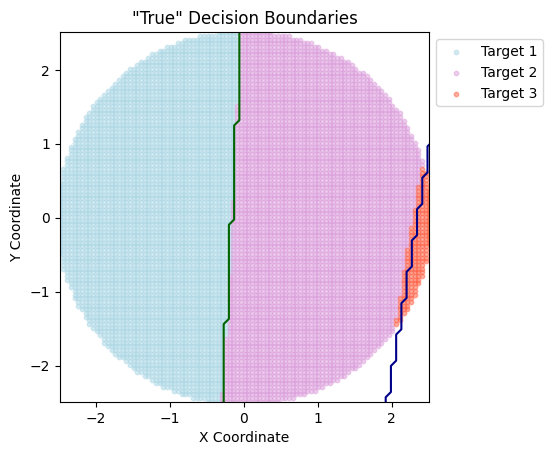

In [81]:
def get_image_data(image_index, test_data):
    start_row = image_index * 8092
    end_row = start_row + 8092
    return test_data.iloc[start_row:end_row]

# Example: Get data for the first image (image_index = 0)
first_image_data = get_image_data(0, X_train)

plot_targets_on_image(first_image_data)


In [43]:
# import seaborn as sns
# sns.pairplot(first_image_data, vars=['x', 'y', 'log_Sn', 'log_Ba'], hue='target', palette=['darkgreen', 'darkgreen'])
# plt.show()

# Enhanced Images

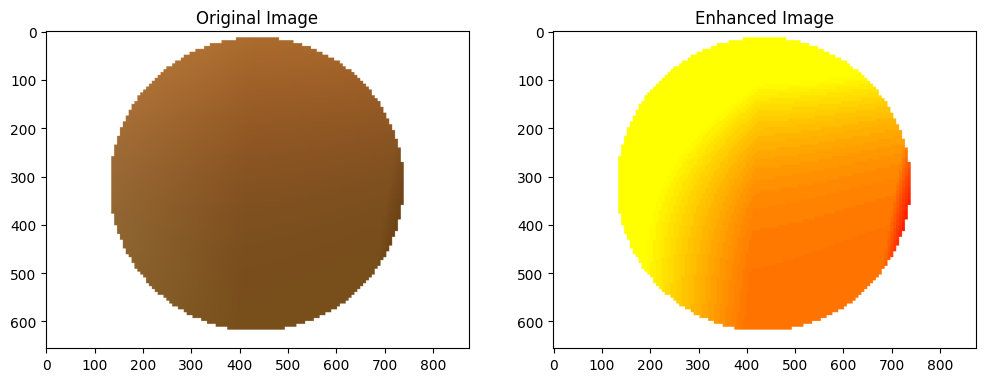

In [108]:
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance

original_image_path = './Filtered_T_Image.tif'
original_image = Image.open(original_image_path)

def enhance_contrast_and_brightness(img, contrast_factor=1.5, brightness_factor=1.2):
    brightness_enhancer = ImageEnhance.Brightness(img)
    brightened_img = brightness_enhancer.enhance(brightness_factor)

    contrast_enhancer = ImageEnhance.Contrast(brightened_img)
    enhanced_img = contrast_enhancer.enhance(contrast_factor)

    return enhanced_img

enhanced_image = enhance_contrast_and_brightness(original_image, contrast_factor=3.0, brightness_factor=2.5)


plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_image, cmap='gray')
plt.title('Original Image')

plt.subplot(1, 2, 2)
plt.imshow(enhanced_image, cmap='gray')
plt.title('Enhanced Image')

plt.show()


# Testing ( debugging )

In [ ]:
# y_test.shape

(404600, 3)

In [ ]:
# X_test[40176:40200], y_test[40176:40200], y_test_pred[40176:40200]

In [ ]:
import cv2

In [ ]:
def get_image_data(image_index, test_data):
    start_row = image_index * 8092
    end_row = start_row + 8092
    return test_data.iloc[start_row:end_row]

# Example: Get data for the first image (image_index = 0)
first_image_data = get_image_data(0, test_data)
print(first_image_data.shape)
first_image_data.head()

(8092, 9)


,x,y,Sn,Ba,F,target,log_Sn,log_Ba,log_F
0,-2.49,-0.49,3.199528e-07,3.478777e-07,0.479093,1,0.144885,0.445961,0.288968
1,-2.49,-0.44,3.189651e-07,3.466478e-07,0.479205,1,0.144169,0.444092,0.289182
2,-2.49,-0.39,3.179702e-07,3.454058e-07,0.479321,1,0.143448,0.442205,0.289404
3,-2.49,-0.34,3.169681e-07,3.441517e-07,0.479441,1,0.142722,0.440300,0.289634
4,-2.49,-0.29,3.159591e-07,3.428860e-07,0.479565,1,0.141991,0.438376,0.289870


In [ ]:
first_image_data.describe()

,x,y,Sn,Ba,F,target,log_Sn,log_Ba,log_F
count,8092.000000,8092.000000,8.092000e+03,8.092000e+03,8092.000000,8092.000000,8092.000000,8092.000000,8092.000000
mean,0.000886,0.000886,4.295004e-07,2.470287e-07,0.631720,1.860109,0.224263,0.292720,0.563631
std,1.268877,1.268877,8.015868e-08,4.616896e-08,0.073770,0.567705,0.058083,0.070154,0.128342
min,-2.490000,-2.490000,2.924399e-07,1.685736e-07,0.479093,1.000000,0.124949,0.173507,0.288968
25%,-1.040000,-1.040000,3.625426e-07,2.085421e-07,0.572715,2.000000,0.175746,0.234239,0.462437
50%,0.010000,0.010000,4.214639e-07,2.423902e-07,0.634787,2.000000,0.218440,0.285672,0.571843
75%,1.010000,1.010000,4.907072e-07,2.823053e-07,0.692934,2.000000,0.268614,0.346323,0.670626
max,2.510000,2.510000,6.134185e-07,3.533566e-07,0.767582,3.000000,0.357530,0.454287,0.792583
